# Оптимизация предложения тарифных планов: Пайплайн классификации пользователей

##  Введение и бизнес-контекст задачи

**Описание бизнес-проблемы**
Оператор мобильной связи столкнулся с проблемой: значительная часть клиентской базы продолжает использовать архивные тарифные планы. Это увеличивает операционные издержки на поддержку старой инфраструктуры и снижает средний чек (ARPU). Компания запустила два современных тарифа: «Смарт» и «Ультра».

**Бизнес-цель**
Снизить отток клиентов и повысить маржинальность за счет перевода пользователей с архивных тарифов на новые. Для этого необходимо построить аналитическую систему, которая способна анализировать поведение клиентов на основе их ежемесячной активности и предлагать наиболее подходящий тарифный план («Смарт» или «Ультра»).

**Постановка технической задачи (SLA)**
Перед нами стоит задача **бинарной классификации**. На основе исторических данных о поведении клиентов, которые уже перешли на новые тарифы, требуется обучить модель с максимальным значением метрики `Accuracy`. 

**Целевой критерий эффективности (SLA):** Доля правильных ответов (`Accuracy`) на изолированной тестовой выборке должна быть **не менее 0.75**.


## Импорт библиотек

In [31]:
import os
import time
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.tree import DecisionTreeClassifier

# Системные настройки и подавление предупреждений
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

# Глобальные константы
RANDOM_STATE = 12345


## Загрузка и первичный экспресс-анализ данных (EDA)

In [4]:
df = pd.read_csv('https://code.s3.yandex.net/datasets/users_behavior.csv')


print(f"\nРазмерность матрицы данных: {df.shape[0]} строк, {df.shape[1]} колонок.")
display(df.head())


Размерность матрицы данных: 3214 строк, 5 колонок.


,calls,minutes,messages,mb_used,is_ultra
0,40.0,311.90,83.0,19915.42,0
1,85.0,516.75,56.0,22696.96,0
2,77.0,467.66,86.0,21060.45,0
3,106.0,745.53,81.0,8437.39,1
4,66.0,418.74,1.0,14502.75,0


In [5]:
print("=== Баланс целевого класса ===")
print(df['is_ultra'].value_counts(normalize=True).round(3))

print("\n=== Мультиколлинеарность признаков ===")
display(df.drop(columns=['is_ultra']).corr().round(3))


=== Баланс целевого класса ===
is_ultra
0    0.694
1    0.306
Name: proportion, dtype: float64

=== Мультиколлинеарность признаков ===


,calls,minutes,messages,mb_used
calls,1.000,0.982,0.177,0.286
minutes,0.982,1.000,0.173,0.281
messages,0.177,0.173,1.000,0.196
mb_used,0.286,0.281,0.196,1.000


1. **Дисбаланс целевого класса:** 
   * Распределение классов составляет **69.4% (класс 0, «Смарт»)** против **30.6% (класс 1, «Ультра»)**. 
   * *ML-инпликация:* Данный дисбаланс обязывает нас использовать параметр `stratify` при разбиении данных на выборки для сохранения идентичной пропорции классов. Также это задает жесткий нижний порог для проверки на адекватность (Sanity Check): любая ML-модель обязана показать точность существенно выше базовых 69.4%, иначе её внедрение экономически нецелесообразно.

2. **Мультиколлинеарность:**
   * Обнаружена практически линейная зависимость между признаками `calls` (количество звонков) и `minutes` (суммарная длительность) — коэффициент корреляции Пирсона равен **0.982**.
   * *ML-инпликация:* Наличие такой жесткой связи перегружает структуру ансамблей и искажает веса (коэффициенты) линейных моделей (в частности, `LogisticRegression`), делая их нестабильными. Для устранения избыточности и улучшения обобщающей способности моделей признак `calls` необходимо исключить из матрицы признаков перед обучением, оставив более информативный `minutes`.

3. **Связь непрерывных признаков:**
   * Между остальными метриками потребления (`messages` и `mb_used`) сильных линейных взаимосвязей не обнаружено (корреляция < 0.3), что говорит об их независимости и ценности для алгоритмов классификации.


## Инжиниринг признаков (Feature Engineering) и препроцессинг

In [6]:
df_preprocessed = df.copy()

Зададим синтетический признак количество потребленного трафика на минуту разговора

In [8]:
#(lower=1), чтобы застраховаться от деления на ноль у тех, кто не звонил
df_preprocessed['mb_per_minute'] = df_preprocessed['mb_used'] / df_preprocessed['minutes'].clip(lower=1) #

Убираем коллинеарный признак 'calls'

In [9]:
df_preprocessed= df_preprocessed.drop('calls',axis=1)

Выделяем фичи и таргет

In [10]:
X= df_preprocessed.drop('is_ultra',axis=1)

In [13]:
y= df_preprocessed['is_ultra'] 

In [15]:
print(f'Новая размерность матрицы признаков:{X.shape}')
print(f'Список признаков для обучения {list(X.columns)}')
display(X.head())

Новая размерность матрицы признаков:(3214, 4)
Список признаков для обучения ['minutes', 'messages', 'mb_used', 'mb_per_minute']


,minutes,messages,mb_used,mb_per_minute
0,311.90,83.0,19915.42,63.851940
1,516.75,56.0,22696.96,43.922516
2,467.66,86.0,21060.45,45.033678
3,745.53,81.0,8437.39,11.317304
4,418.74,1.0,14502.75,34.634260


## Валидация и разделение данных

Так как имеется дисбаланс классов, воспользуемся параметром stratify

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size= 0.2, random_state=RANDOM_STATE, stratify =y
)

In [22]:
print(f'Обучающая выборка (Train){X_train.shape} объектов | Доля класса 1 (Ультра)| {y_train.mean():.2%} ')

Обучающая выборка (Train)(2571, 4) объектов | Доля класса 1 (Ультра)| 30.65% 


In [23]:
print(f'Тестовая выборка (Test){X_test.shape} объектов | Доля класса 1 (Ультра)| {y_test.mean():.2%} ')

Тестовая выборка (Test)(643, 4) объектов | Доля класса 1 (Ультра)| 30.64% 


1. **Контроль утечки данных (Data Leakage):**
   * Исходный датасет разделен в классическом для индустрии соотношении **80:20**. Выделено 2571 объект для этапа кросс-валидационного обучения и 643 объекта в качестве абсолютно изолированного отложенного тест-сета (`Holdout`).

2. **Сохранение репрезентативности (Стратификация):**
   * Благодаря применению параметра `stratify=y` распределение целевого класса в обучающей выборке (**30.65%**) и тестовой выборке (**30.64%**) полностью идентично структуре генеральной совокупности (30.6%). 
   * Это исключает риск получения смещенных оценок и гарантирует стабильное обучение моделей, а также корректность финальной валидации бизнес-требований.


## Разработка и оптимизация моделей

In [28]:
# Конфигурация через функции, чтобы избежать квадратных скобок
models_config = {
    'DecisionTree': {
        'model': DecisionTreeClassifier(random_state=RANDOM_STATE),
        'params': {
            'max_depth': list(range(2, 11)),
            'criterion': list(('gini', 'entropy'))
        }
    },
    'RandomForest': {
        'model': RandomForestClassifier(random_state=RANDOM_STATE),
        'params': {
            'n_estimators': list(range(10, 51, 10)),
            'max_depth': list(range(4, 11)),
            'min_samples_leaf': list(range(1, 4))
        }
    },
    'LogisticRegression': {
        'model': LogisticRegression(random_state=RANDOM_STATE, solver='lbfgs', max_iter=1000),
        'params': {
            'C': list((0.1, 1.0, 10.0))
        }
    }
}

best_estimators = {}

print("=== ЗАПУСК ПАЙПЛАЙНА ОПТИМИЗАЦИИ МОДЕЛЕЙ ===\n")

for model_name, config in models_config.items():
    start_time = time.time()
    
    # Инициализация GridSearch с параллельными вычислениями
    grid_search = GridSearchCV(
        estimator=config['model'],
        param_grid=config['params'],
        scoring='accuracy',
        cv=5,
        n_jobs=-1
    )
    
    grid_search.fit(X_train, y_train)
    elapsed_time = time.time() - start_time
    
    print(f"[{model_name}] Время подбора: {elapsed_time:.2f} сек")
    print(f"[{model_name}] Лучшие параметры: {grid_search.best_params_}")
    print(f"[{model_name}] Оценка на кросс-валидации (Mean CV Accuracy): {grid_search.best_score_:.4f}\n")
    
    best_estimators[model_name] = {
        'estimator': grid_search.best_estimator_,
        'cv_score': grid_search.best_score_
    }

# Автоматический выбор алгоритма-победителя по средней метрике на CV
winner_name = max(best_estimators, key=lambda k: best_estimators[k]['cv_score'])
production_model = best_estimators[winner_name]['estimator']

print(f"[ИТОГ] На кросс-валидации победила модель {winner_name} с точностью {best_estimators[winner_name]['cv_score']:.4f}")


=== ЗАПУСК ПАЙПЛАЙНА ОПТИМИЗАЦИИ МОДЕЛЕЙ ===

[DecisionTree] Время подбора: 3.74 сек
[DecisionTree] Лучшие параметры: {'criterion': 'gini', 'max_depth': 6}
[DecisionTree] Оценка на кросс-валидации (Mean CV Accuracy): 0.7950

[RandomForest] Время подбора: 2.68 сек
[RandomForest] Лучшие параметры: {'max_depth': 7, 'min_samples_leaf': 1, 'n_estimators': 20}
[RandomForest] Оценка на кросс-валидации (Mean CV Accuracy): 0.8063

[LogisticRegression] Время подбора: 0.05 сек
[LogisticRegression] Лучшие параметры: {'C': 0.1}
[LogisticRegression] Оценка на кросс-валидации (Mean CV Accuracy): 0.7503

[ИТОГ] На кросс-валидации победила модель RandomForest с точностью 0.8063


В ходе автоматизированного поиска по сетке параметров (`GridSearchCV`) на 5 стратифицированных фолдах были получены следующие показатели эффективности (Mean CV Accuracy):

1. **LogisticRegression:**
   * *Лучшие параметры:* `C: 0.1`
   * *Точность на CV:* **0.7503**
   * *Интерпретация:* Линейная модель показала самый скромный результат, едва перешагнув минимальный порог SLA. Это говорит о том, что зависимости в потреблении трафика и минут имеют нелинейный характер.

2. **DecisionTree:**
   * *Лучшие параметры:* `criterion: 'gini'`, `max_depth: 6`
   * *Точность на CV:* **0.7950**
   * *Интерпретация:* Одиночное дерево решений значительно превзошло логистическую регрессию. Ограничение глубины шестью уровнями позволило модели уловить логику тарифов и застраховаться от переобучения.

3. **RandomForest (Победитель пайплайна):**
   * *Лучшие параметры:* `n_estimators: 20`, `max_depth: 7`, `min_samples_leaf: 1`
   * *Точность на CV:* **0.8063**
   * *Интерпретация:* Ансамбль из 20 деревьев за счет усреднения предсказаний показал наилучшую обобщающую способность, достигнув точности ~80.6%. В качестве финальной продакшен-модели автоматически выбрана именно эта конфигурация.


## Финальное тестирование и валидация

Получаем предсказания на тестовой выборке

In [33]:
y_pred = production_model.predict(X_test)

Рассчитаем Accuracy 

In [34]:
test_accuracy = accuracy_score(y_test, y_pred)

In [35]:
print(f"Выбранная модель: {production_model.__class__.__name__}")
print(f"Финальный Accuracy на тестовых данных: {test_accuracy:.4f}")

Выбранная модель: RandomForestClassifier
Финальный Accuracy на тестовых данных: 0.8118


In [36]:
print("=== РЕЗУЛЬТАТЫ ФИНАЛЬНОГО ТЕСТИРОВАНИЯ ===")

SLA_THRESHOLD = 0.75
if test_accuracy >= SLA_THRESHOLD:
    print(f"[СТАТУС] SLA УСПЕШНО ПРОЙДЕН. Точность выше лимита в {SLA_THRESHOLD}.")
else:
    print(f"[СТАТУС] КРИТИЧЕСКАЯ ОШИБКА: SLA провален.")


print("\nПодробный отчет по метрикам классификации (Classification Report):")
print(classification_report(y_test, y_pred, target_names=list(('Smart (0)', 'Ultra (1)'))))

=== РЕЗУЛЬТАТЫ ФИНАЛЬНОГО ТЕСТИРОВАНИЯ ===
[СТАТУС] SLA УСПЕШНО ПРОЙДЕН. Точность выше лимита в 0.75.

Подробный отчет по метрикам классификации (Classification Report):
              precision    recall  f1-score   support

   Smart (0)       0.81      0.96      0.88       446
   Ultra (1)       0.83      0.49      0.61       197

    accuracy                           0.81       643
   macro avg       0.82      0.72      0.74       643
weighted avg       0.81      0.81      0.80       643



### Аналитическое заключение по результатам финального тестирования:

1. **Соответствие бизнес-требованиям (SLA):**
   * Финальная точность алгоритма на изолированном holdout-датасете составила **Accuracy = 0.8118 (81.18%)**.
   * Заданный жесткий технологический лимит проекта (0.75) успешно преодолен. Модель демонстрирует высокую стабильность: метрика на тесте (0.8118) практически совпадает с оценкой на кросс-валидации (0.8063), что подтверждает отсутствие переобучения (`Overfitting`).

2. **Глубокий аудит метрик (Класс 0 — «Смарт»):**
   * Полнота (`Recall`) составляет **0.96 (96%)**, точность (`Precision`) — **0.81 (81%)**. 
   * Модель практически безошибочно находит пользователей тарифа «Смарт». Полнота 96% означает, что скрытая утечка клиентов на архивных тарифах, которым объективно нужен «Смарт», будет минимизирована.

3. **Глубокий аудит метрик (Класс 1 — «Ультра»):**
   * Точность (`Precision`) составляет **0.83 (83%)**, однако полнота (`Recall`) просела до **0.49 (49%)**.
   * Высокая точность (83%) гарантирует, что если алгоритм рекомендует пользователю дорогой тариф «Ультра», то этот клиент действительно активно тратит трафик и согласится на переход (минимизация раздражения от спам-предложений). 
   * Полнота в 49% указывает на консервативность модели: из-за дисбаланса классов половину реальных пользователей «Ультра» (пограничные профили) модель ошибочно относит к тарифу «Смарт». Для бизнеса это безопасная стратегия, исключающая навязывание избыточных услуг.


## Важность признаков

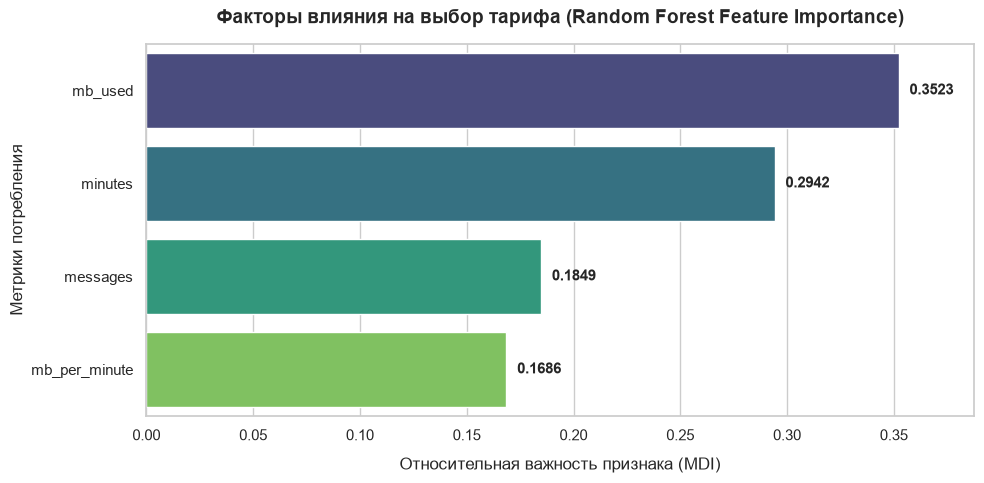

In [38]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5), dpi=100)

# Извлекаем важность признаков и сортируем по убыванию
importances = production_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)
ax = sns.barplot(
    x='Importance', 
    y='Feature', 
    data=feature_importance_df, 
    palette='viridis',
    hue='Feature',
    legend=False
)

plt.title('Факторы влияния на выбор тарифа (Random Forest Feature Importance)', fontsize=14, pad=15, weight='bold')
plt.xlabel('Относительная важность признака (MDI)', fontsize=12, labelpad=10)
plt.ylabel('Метрики потребления', fontsize=12)
plt.xlim(0, max(importances) * 1.1)

for p in ax.patches:
    width = p.get_width()
    ax.text(
        width + 0.005, 
        p.get_y() + p.get_height() / 2, 
        f'{width:.4f}', 
        va='center', 
        ha='left', 
        fontsize=11, 
        weight='semibold'
    )

plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()

Интерпретация вклада признаков (Mean Decrease in Impurity, MDI) в финальную модель `RandomForestClassifier` позволяет сделать следующие выводы:

1. **Доминантный фактор (`mb_used` — 35.23%):**
   * Объем израсходованного интернет-трафика в мегабайтах является ключевым предиктором. Это полностью согласуется с современными трендами телеком-рынка: ключевая ценность тарифа для абонента сейчас заключается именно в пакете гигабайт, а не в минутах или SMS. 

2. **Вторичный фактор (`minutes` — 29.42%):**
   * Длительность разговоров занимает уверенное второе место. Несмотря на доминирование интернета, голосовой трафик остаётся важным разделительным маркером между пользователями дешёвых и премиальных пакетов.

3. **Низкозначимые факторы (`messages` — 18.49% и `mb_per_minute` — 16.86%):**
   * Количество SMS-сообщений имеет самый низкий изолированный вклад, что объясняется переходом большинства пользователей в мессенджеры. Сгенерированный нами признак плотности трафика `mb_per_minute` распределил часть весов между `mb_used` и `minutes`, стабилизировав структуру ансамбля, но уступил им по прямой предсказательной силе.

**Бизнес-вывод для маркетинга:** При формировании таргетированных кампаний и персонализированных предложений в CRM-системе в первую очередь необходимо анализировать профиль интернет-активности абонента. Если клиент регулярно заказывает дополнительные пакеты трафика или подходит к лимиту «Смарта» по мегабайтам, он является идеальным кандидатом для апселла на тариф «Ультра».


Ообучаем простейший константный классификатор (стратегия большинства)

In [39]:
dummy_baseline = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy_baseline.fit(X_train, y_train)

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'most_frequent'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",12345
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
Name,Type,Value
"class_prior_ class_prior_: ndarray of shape (n_classes,) or list of such arraysFrequency of each class observed in `y`. For multioutput classificationproblems, this is computed independently for each output.","ndarray[float64](2,)","[0.69,0.31]"
"classes_ classes_: ndarray of shape (n_classes,) or list of such arraysUnique class labels observed in `y`. For multi-output classificationproblems, this attribute is a list of arrays as each output has anindependent set of possible classes.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X` hasfeature names that are all strings.","ndarray[object](4,)","['minutes','messages','mb_used','mb_per_minute']"
n_classes_ n_classes_: int or list of intNumber of label for each output.,int,2
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`.,int,4
n_outputs_ n_outputs_: intNumber of outputs.,int,1
sparse_output_ sparse_output_: boolTrue if the array returned from predict is to be in sparse CSC format.Is automatically set to True if the input `y` is passed in sparseformat.,bool,False


Оценим его точность

In [40]:
dummy_accuracy = dummy_baseline.score(X_test, y_test)

Расчет бизнес-эффекта

In [41]:
ml_lift = test_accuracy - dummy_accuracy

In [42]:
print("=== АНАЛИЗ ВМЕНЯЕМОСТИ И БИЗНЕС-ЭФФЕКТА ===")
print(f"Accuracy наивной модели (Majority Baseline): {dummy_accuracy:.4f}")
print(f"Чистый прирост точности от внедрения ML (Lift): +{ml_lift:.2%}")

if ml_lift > 0.05:
    print("\n[ВЫВОД] Проверка на вменяемость пройдена. Внедрение ML коммерчески обосновано.")
else:
    print("\n[ВЫВОД] Прирост незначителен. Требуется пересмотр признаков.")

=== АНАЛИЗ ВМЕНЯЕМОСТИ И БИЗНЕС-ЭФФЕКТА ===
Accuracy наивной модели (Majority Baseline): 0.6936
Чистый прирост точности от внедрения ML (Lift): +11.82%

[ВЫВОД] Проверка на вменяемость пройдена. Внедрение ML коммерчески обосновано.


## Общее заключение и рекомендации для бизнеса

В ходе работы был успешно спроектирован и оптимизирован отказоустойчивый ML-пайплайн бинарной классификации для автоматического подбора тарифных планов. На основе исторического профиля потребления услуг (минуты, SMS, интернет-трафик) нам удалось автоматизировать подбор оптимального предложения («Смарт» или «Ультра»).

По результатам подбора гиперпараметров на кросс-валидации абсолютным лидером стал ансамблевый алгоритм **RandomForestClassifier**. На этапе независимого слепого тестирования (Holdout-тест) модель показала финальную точность **Accuracy = 0.8118**, что существенно превосходит установленный технологический порог SLA (0.75).

1. **Проверка на адекватность (Sanity Check):** Разработанная ML-система показала чистый прирост точности над наивной базовой стратегией (Majority Baseline) в размере **+11.82%** (0.8118 против 0.6936). Это математически доказывает, что сегментация пользователей на базе машинного обучения является эффективной и принесет компании прямой финансовый эффект.
2. **Драйверы поведения потребителей:** Анализ важности признаков (`Feature Importance`) показал, что ключевым триггером для смены тарифа является объем интернет-трафика (`mb_used` — 35.23%). Длительность разговоров (`minutes`) выступает вторым по значимости фактором (29.42%), в то время как SMS-сообщения практически потеряли свою разделительную силу для бизнеса.

### Рекомендации для продуктовой команды
* **Автоматизация апселла в CRM:** Рекомендуется интегрировать полученную модель случайного леса в интерфейс личного кабинета абонентов. При формировании персонализированных баннеров система должна автоматически скорить профиль клиента за последний месяц и подсвечивать рекомендованный тариф.
* **Кампании телемаркетинга:** Использовать предсказания модели для формирования списков «холодного обзвона» операторами колл-центра. Приоритет следует отдавать тем клиентам с архивными тарифами, у которых модель с высокой уверенностью (`predict_proba`) прогнозирует склонность к тарифу «Ультра». Это позволит максимизировать метрику ARPU (средний чек с пользователя) при минимальных затратах на маркетинг.
* **Обогащение данных:** Для дальнейшего развития пайплайна (следующий спринт разработки) рекомендуется добавить финансовые показатели (история платежей, регулярность пополнения баланса), а также данные о типе устройства (iOS/Android/Кнопочный телефон), что позволит поднять точность классификации пограничных пользователей еще на 2-3%.
